In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

In [17]:
df = pd.read_csv("https://raw.githubusercontent.com/sundharhug24ad-cloud/exp1ml/refs/heads/main/student_performance_updated_1000.csv")

print(df.head())
print(df.shape)

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                False  
1          2.2            70.0  

In [18]:
df["Result"] = (df["FinalGrade"] >= 50).astype(int)

print(df["Result"].value_counts())

Result
1    960
0     40
Name: count, dtype: int64


In [19]:
features = [
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "ExtracurricularActivities",
    "Study Hours",
    "Attendance (%)"
]

X = df[features]
y = df["Result"]

In [20]:
data = pd.concat([X, y], axis=1).dropna()

X = data[features]
y = data["Result"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (636, 6)
Testing data: (159, 6)


In [22]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1]


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9559748427672956
Accuracy (%): 95.59748427672956


In [25]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  1   5]
 [  2 151]]


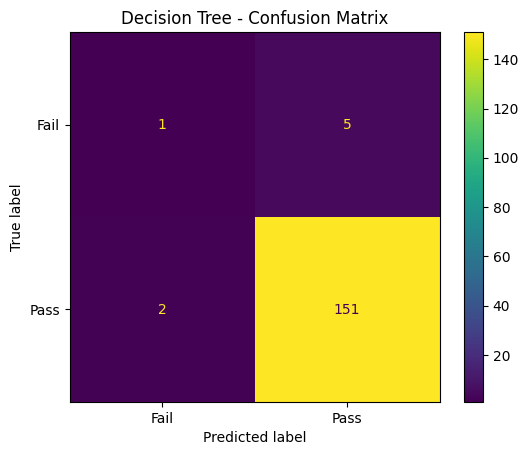

In [26]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [27]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"]
))

              precision    recall  f1-score   support

        Fail       0.33      0.17      0.22         6
        Pass       0.97      0.99      0.98       153

    accuracy                           0.96       159
   macro avg       0.65      0.58      0.60       159
weighted avg       0.94      0.96      0.95       159



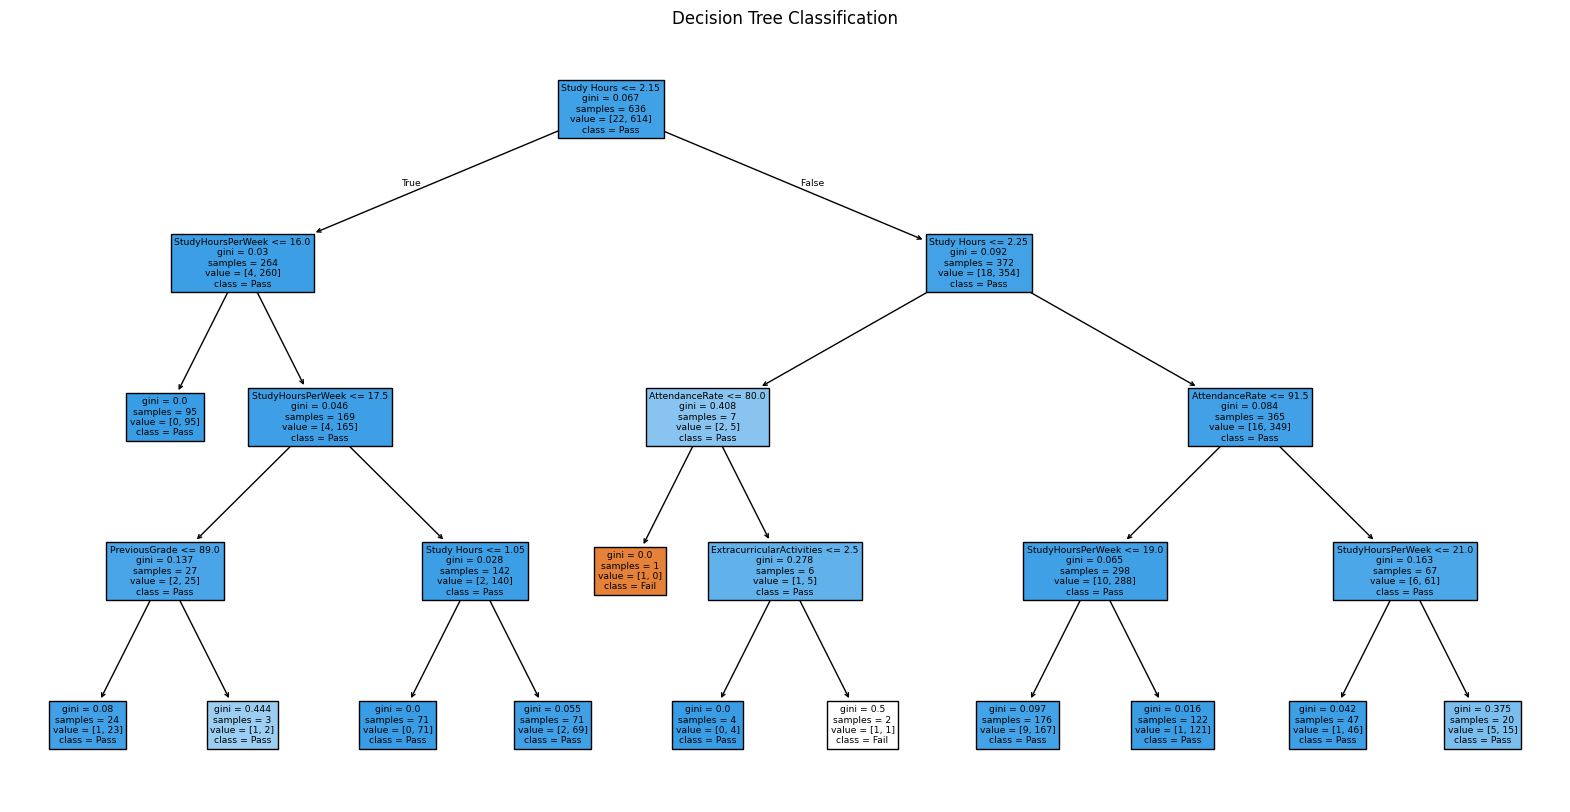

In [28]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=features,
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree Classification")
plt.show()